# Photometry - Anscombe TDV
```Authors: Paul Alvarez updated: 20262109```


El presente notebook explora la incoporación de métricas más robustas para el análisis del resultado de la imagen ruidosa en astronomía, adicionales a evaluación directa que otorgan los valores $PSNR$ o $SSIM$. Dentro de ello, se busca evaluar la conservación del flujo total (fotometría), el desplazamiento del centroide (astrometría) y la media y estructura del residuo ($r = z_{noisy} - x_{denoised}$). Adicionalmente, se evaluará el rendimiento de Total Deep Variation aplicando la transformada de Anscombe al ruido Poisson esperado de una imagen astronómica.

In [1]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)

In [2]:
# requeriments
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from tdv.denoise_utils import apply_vn, check_color, denoise_z, load_model, psnr, test_img
from skimage.metrics import structural_similarity as ssim
from notebooks.utils import plot_results, add_gp_noise, add_poisson_noise, add_gaussian_noise, minimax_norm, test_astro
from skimage import data, img_as_float
from astropy.io import fits
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus
from astropy.stats import mad_std
from astropy.visualization import simple_norm, AsinhStretch, SqrtStretch, LogStretch
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

## Setup

In [9]:
fits_sim = 'm20_greennoise_G.tif'
img_path1 = os.path.join('..', 'data', fits_sim)
z_raw = tifffile.imread(img_path1).astype(np.float32)

60 stars found


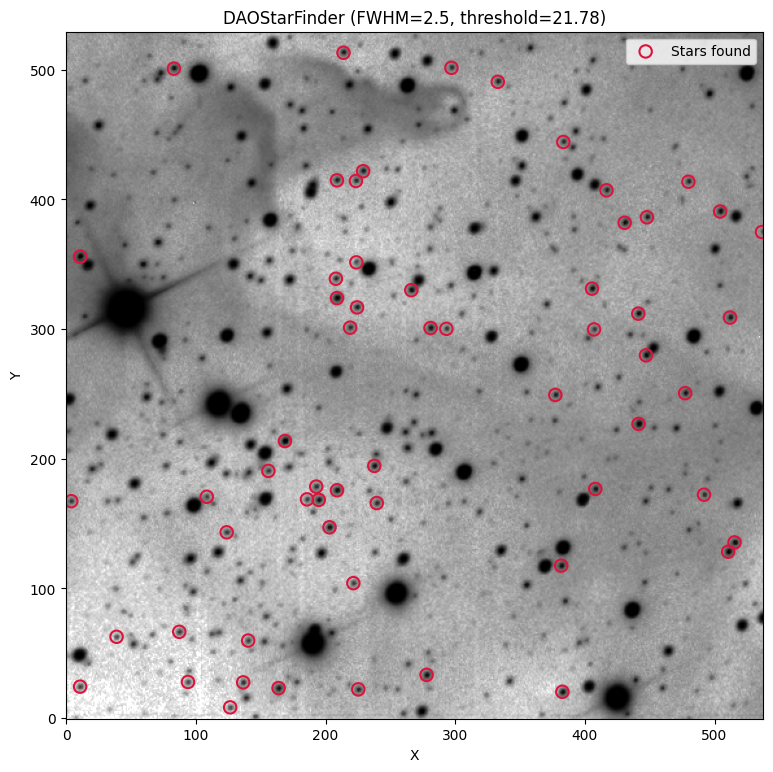

In [10]:
# Search example
data = z_raw
mean, median, std = sigma_clipped_stats(data, sigma=3.0)
data_bkg_subtracted = data - median
fwhm_estimado = 2.5 #widtch star
fwhm = fwhm_estimado
daofind = DAOStarFinder(fwhm=fwhm_estimado, threshold= 3.5 * std)
sources = daofind(data_bkg_subtracted)

norm = simple_norm(data, 'sqrt', percent=99.2)
print(f"{len(sources)} stars found")
plt.figure(figsize=(9, 9))
plt.imshow(data, cmap='Greys', origin='lower', norm=norm)
plt.scatter(sources['x_centroid'], sources['y_centroid'], s=80, facecolors='none', edgecolors='crimson', linewidths=1.5, label='Stars found')
plt.legend(loc='upper right')

plt.title(f"DAOStarFinder (FWHM={fwhm}, threshold={std:.2f})")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [11]:
def photometry_val(x, img_coords_ref=None):
    if img_coords_ref is None:img_coords_ref = x

    mean, median, std = sigma_clipped_stats(img_coords_ref, sigma=3.0)
    data_bkg_subtracted = img_coords_ref - median

    daofind = DAOStarFinder(fwhm=2.5, threshold=3.5 * std)
    sources = daofind(data_bkg_subtracted)
    positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
    apertures = CircularAperture(positions, r=6.0)       
    rings = CircularAnnulus(positions, r_in=12.0, r_out=15.0) 

    phot_df = aperture_photometry(x, [apertures, rings])
    raw_flux = np.array(phot_df['aperture_sum_0'])
    ring_flux = np.array(phot_df['aperture_sum_1'])
    
    ring_flux_per_pix = ring_flux / rings.area
    bias_flux = ring_flux_per_pix * apertures.area
    true_flux = raw_flux - bias_flux

    return true_flux

In [13]:
true_flux_z = photometry_val(z_raw)
print(f"Total flux over z raw (noised) {sum(true_flux_z):.2f}")

Total flux over z raw (noised) 203435.75


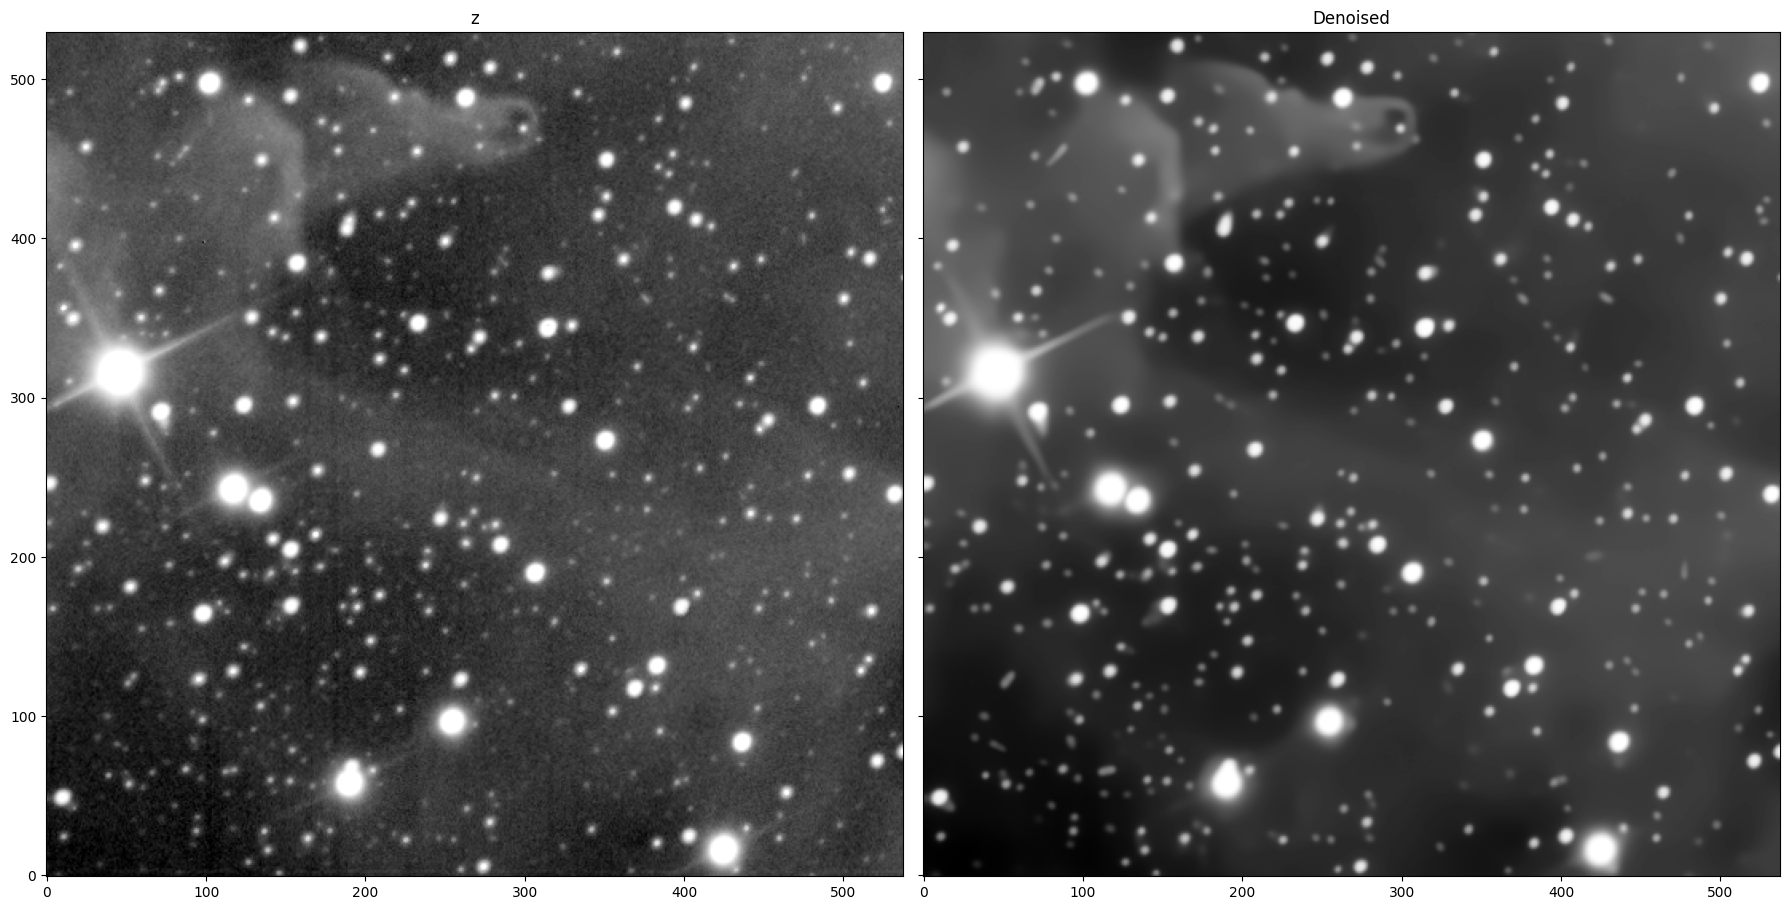

In [7]:
z_noised, x_denoised = test_astro(fits_sim, type='tif', norm=False)
plot_results(z_noised, x_denoised, figsize=(18, 12))

In [36]:
x_denoised_raw = x_denoised * 255
true_flux_x = photometry_val(x_denoised_raw)
print(f"Total flux over x raw (denoised) {sum(true_flux_z):.2f}")

RuntimeError: filter weights array has incorrect shape.

In [ ]:
x_denoide

In [21]:

def metric_residual(y_clean, z_noised, x_denoised):
    residual = z_noised - x_denoised
    
    corr_matrix = np.corrcoef(residual.ravel(), y_clean.ravel())
    leakage_corr = float(corr_matrix[0, 1])
    res_mean = float(np.mean(residual))
    
    return leakage_corr, res_mean